<a href="https://colab.research.google.com/github/rohitboltfree/Pyhon01/blob/main/Zomato_forTheStreet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "BangaloreZomatoData.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "vora1011/zomato-bangalore-restaurants-2022",
    file_path,
)

print("First 10 records :")
print(df.head())

100%|██████████| 702k/702k [00:00<00:00, 837kB/s]

Extracting zip of BangaloreZomatoData.csv...
First 10 records :
                   Name                                                URL  \
0        Sri Udupi Park  https://www.zomato.com/bangalore/sri-udupi-par...   
1         Meghana Foods  https://www.zomato.com/bangalore/meghana-foods...   
2  Donne Biriyani House  https://www.zomato.com/bangalore/donne-biriyan...   
3        Domino's Pizza  https://www.zomato.com/bangalore/dominos-pizza...   
4                   KFC   https://www.zomato.com/bangalore/kfc-indiranagar   

                                            Cuisines                    Area  \
0  South Indian, North Indian, Chinese, Street Fo...  Indiranagar, Bangalore   
1             Biryani, Andhra, North Indian, Seafood  Indiranagar, Bangalore   
2                                            Biryani  Indiranagar, Bangalore   
3                         Pizza, Fast Food, Desserts  Indiranagar, Bangalore   
4    Burger, Fast Food, Biryani, Desserts, Beverages  Indiranagar, 

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8923 entries, 0 to 8922
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Name              8923 non-null   object
 1   URL               8923 non-null   object
 2   Cuisines          8923 non-null   object
 3   Area              8923 non-null   object
 4   Timing            5820 non-null   object
 5   Full_Address      8923 non-null   object
 6   PhoneNumber       8923 non-null   object
 7   IsHomeDelivery    8923 non-null   int64 
 8   isTakeaway        8923 non-null   int64 
 9   isIndoorSeating   8923 non-null   int64 
 10  isVegOnly         8923 non-null   int64 
 11  Dinner Ratings    8923 non-null   object
 12  Dinner Reviews    8923 non-null   int64 
 13  Delivery Ratings  8923 non-null   object
 14  Delivery Reviews  8923 non-null   int64 
 15  KnownFor          258 non-null    object
 16  PopularDishes     1535 non-null   object
 17  PeopleKnownFor

In [3]:
df.describe()

,IsHomeDelivery,isTakeaway,isIndoorSeating,isVegOnly,Dinner Reviews,Delivery Reviews,AverageCost
count,8923.000000,8923.000000,8923.000000,8923.000000,8923.000000,8923.000000,8923.000000
mean,0.997871,0.660092,0.442676,0.072285,157.106018,2014.709403,340.225261
std,0.046098,0.473704,0.496731,0.258974,731.834227,5524.430542,308.338943
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,42.000000,150.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,279.000000,250.000000
75%,1.000000,1.000000,1.000000,0.000000,43.000000,1493.500000,400.000000
max,1.000000,1.000000,1.000000,1.000000,26500.000000,99600.000000,4200.000000


In [4]:
df['KnownFor']=df["KnownFor"].fillna("unknown")
df.isnull().sum()
# df.duplicated().sum()

,0
Name,0
URL,0
Cuisines,0
Area,0
Timing,3103
Full_Address,0
PhoneNumber,0
IsHomeDelivery,0
isTakeaway,0
isIndoorSeating,0


In [5]:
# to fix the captial columns name and space in the columns name

# first to replace clumns name space with underscore
df.columns  = df.columns.str.replace(" ","_")
# or you can use the stip() to remove the remaining space
df.columns = df.columns.str.strip()
# and you can convert the capital case with the lower to ease in the coding
df.columns  = df.columns.str.lower()
# and then print the column data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8923 entries, 0 to 8922
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   name              8923 non-null   object
 1   url               8923 non-null   object
 2   cuisines          8923 non-null   object
 3   area              8923 non-null   object
 4   timing            5820 non-null   object
 5   full_address      8923 non-null   object
 6   phonenumber       8923 non-null   object
 7   ishomedelivery    8923 non-null   int64 
 8   istakeaway        8923 non-null   int64 
 9   isindoorseating   8923 non-null   int64 
 10  isvegonly         8923 non-null   int64 
 11  dinner_ratings    8923 non-null   object
 12  dinner_reviews    8923 non-null   int64 
 13  delivery_ratings  8923 non-null   object
 14  delivery_reviews  8923 non-null   int64 
 15  knownfor          8923 non-null   object
 16  populardishes     1535 non-null   object
 17  peopleknownfor

In [6]:
# because we have object data type we have to handle null values and change the
# to unknown

df['timing']=df["timing"].fillna("unknown")
df['peopleknownfor']=df["peopleknownfor"].fillna("unknown")
df['populardishes']=df["populardishes"].fillna("unknown")

df.isnull().sum()

,0
name,0
url,0
cuisines,0
area,0
timing,0
full_address,0
phonenumber,0
ishomedelivery,0
istakeaway,0
isindoorseating,0


In [7]:
# now check the duplicate values and drop them is any
df.duplicated().sum()

np.int64(0)

In [8]:
print( df['populardishes'].nunique())
print( df['populardishes'].unique())

1536
['Filtered Coffee, Sambhar, Pav Bhaji, Gobi Manchurian'
 'Authentic Hyderabadi Biryani, Paneer Biryani, Panner Tikka, Chicken 65, Lemon Chicken, Mutton Biriyani'
 'unknown' ...
 'Dahi Sev Puri, Dahi Samosa, Healthy Veg Food, Thandai, Sabudana, Khichadi'
 'Seafood, Chicken Ghee Roast, Sea Food, Prawns'
 'Neer Dosa, Chicken Ghee Roast, Seafood, Crab, Sea Food, Prawns']


In [9]:
df['cuisines'] = df['cuisines'].str.title()
print( df['cuisines'].nunique())
print( df['cuisines'].unique())

2939
['South Indian, North Indian, Chinese, Street Food, Biryani, Ice Cream, Beverages, Shake'
 'Biryani, Andhra, North Indian, Seafood' 'Biryani' ...
 'Seafood, Mangalorean, Beverages' 'Salad, Chinese' 'Thai, Chinese']


In [10]:
print(df['peopleknownfor'].nunique())
print(df['peopleknownfor'].unique())

3425
['Economical, Prompt Service, Hygiene, Quality Food, Reasonable Price, Quick Service'
 'Boneless Chicken Biryani, Ample Seating Area, Serving Size, Family Place, Relaxed Atmosphere, Delivery Person'
 'Great Recommendations, Nice Taste, Great Ambiance, Good Quantity, Excellent Food, Nice Food'
 ...
 'Authentic, Cashless Payments, Preparation, Decent Place, Courteous Staff, Excellent Food'
 'Contactless Delivery, Portion, Great Portions, Quality, Price, Packaging'
 'Calm, Prompt Service, Portions, Spicy, Delicious Food, Quantity']


In [22]:
import pandas as pd
df.to_csv('clean_zomato_data.csv', index='false')
df = pd.read_csv("clean_zomato_data.csv")
df.head()

,Unnamed: 0,name,url,cuisines,area,timing,full_address,phonenumber,ishomedelivery,istakeaway,isindoorseating,isvegonly,dinner_ratings,dinner_reviews,delivery_ratings,delivery_reviews,knownfor,populardishes,peopleknownfor,averagecost
0,0,Sri Udupi Park,https://www.zomato.com/bangalore/sri-udupi-par...,"South Indian, North Indian, Chinese, Street Fo...","Indiranagar, Bangalore",7am – 11pm (Today),"273, Monalisa, 6th Main, 100 Feet Road, Indira...",+919945977774,1,1,1,1,4.0,462,4.1,16000,unknown,"Filtered Coffee, Sambhar, Pav Bhaji, Gobi Manc...","Economical, Prompt Service, Hygiene, Quality F...",450
1,1,Meghana Foods,https://www.zomato.com/bangalore/meghana-foods...,"Biryani, Andhra, North Indian, Seafood","Indiranagar, Bangalore",Opens at 6:30pm,"544, First Floor, CMH Road, Near Indiranagar M...",+918041135050,1,1,1,0,4.3,1654,4.3,28600,Spicy Chicken Biryani,"Authentic Hyderabadi Biryani, Paneer Biryani, ...","Boneless Chicken Biryani, Ample Seating Area, ...",700
2,2,Donne Biriyani House,https://www.zomato.com/bangalore/donne-biriyan...,Biryani,"Indiranagar, Bangalore",11am – 11pm (Today),"8/ 9, 17th F Cross, 2nd Stage, Indiranagar, Ba...",+918861564169,1,1,1,0,3.9,411,3.5,33200,unknown,unknown,"Great Recommendations, Nice Taste, Great Ambia...",300
3,3,Domino's Pizza,https://www.zomato.com/bangalore/dominos-pizza...,"Pizza, Fast Food, Desserts","Indiranagar, Bangalore",10:57am – 12midnight (Today),"308, 2nd Stage, 100 Feet Road, Indiranagar, Ba...",+919916465787,1,1,1,0,2.4,422,4.4,8205,unknown,"Barbeque Chicken Pizza, Choco Lava Cake, White...","Value for Money, Packaging, Staff, Ambience, Food",400
4,4,KFC,https://www.zomato.com/bangalore/kfc-indiranagar,"Burger, Fast Food, Biryani, Desserts, Beverages","Indiranagar, Bangalore",11am – 11pm (Today),"38/1A, CMH Road, Indiranagar, Bangalore",+919513700040,1,1,1,0,2.8,673,4.0,9148,unknown,"Fiery Chicken, Chicken Popcorn, Rice Bowl, Wings","Elegantly Decorated, Great Recommendations, Vi...",400


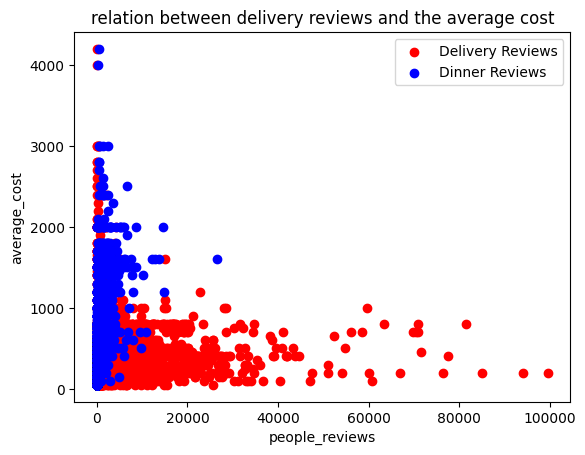

In [31]:
# lets check some relationship between data
import matplotlib.pyplot as plt

plt.scatter(
    df["delivery_reviews"],
    df["averagecost"],
    color="red",
    label="Delivery Reviews"
)

plt.scatter(
    df["dinner_reviews"],
    df["averagecost"],
    color="blue",
    label="Dinner Reviews"
)
plt.xlabel("people_reviews")
plt.ylabel("average_cost")
plt.legend()
plt.title("relation between delivery reviews and the average cost")
plt.show()

In [12]:
# import pandas as pd
# import numpy as np

# # 1. Identify columns dynamically using lowercase lookups
# rating_col = [col for col in df.columns if 'rate' in col.lower() or 'rating' in col.lower()]
# cost_col = [col for col in df.columns if 'cost' in col.lower()]

# # Create a clean copy of the dataframe
# df_clean = df.copy()

# # 2. Robust Cleaning for the Rating Column
# if rating_col:
#     target_rating = rating_col[0]

#     def strict_clean_rating(val):
#         if pd.isna(val):
#             return np.nan
#         val_str = str(val).strip().upper()
#         # Handle common messy placeholders in Zomato data
#         if val_str in ['-', 'NEW', '', 'NONE', 'NA']:
#             return np.nan
#         # Handle "4.1/5" formats
#         if '/' in val_str:
#             val_str = val_str.split('/')[0].strip()
#         try:
#             return float(val_str)
#         except ValueError:
#             return np.nan

#     df_clean[target_rating] = df_clean[target_rating].apply(strict_clean_rating)

# # 3. Robust Cleaning for the Cost Column
# if cost_col:
#     target_cost = cost_col[0]
#     # Remove commas and non-numeric fluff, then force to numeric
#     df_clean[target_cost] = df_clean[target_cost].astype(str).str.replace(',', '').str.strip()
#     df_clean[target_cost] = pd.to_numeric(df_clean[target_cost], errors='coerce')

# # 4. Remove exact duplicate rows
# df_clean.drop_duplicates(inplace=True)

# # 5. Build Dynamic Presentation Styles safely
# format_dict = {}
# subset_cols = []

# if rating_col:
#     format_dict[rating_col[0]] = "{:.1f}"
#     subset_cols.append(rating_col[0])

# if cost_col:
#     format_dict[cost_col[0]] = "₹{:,}"

# # Generate the beautiful styled output
# styled_view = (df_clean.head(10).style
#                .format(format_dict, na_rep="N/A")
#                .set_properties(**{'text-align': 'left'})
#                .set_table_styles([dict(selector='th', props=[('background-color', '#f4f4f4')])]))

# # Apply the gradient safely now that strings are guaranteed to be gone
# if subset_cols:
#     styled_view = styled_view.background_gradient(subset=subset_cols, cmap="YlGn")

# # Display in Google Colab / Jupyter
# styled_view